# 02. Exploración y hallazgos

Este notebook carga las tablas originales y las tablas preparadas por 01_descripcion_y_calidad.ipynb. La unidad de observación cambia explícitamente según la pregunta: snapshot de una versión Markdown, archivo lógico (repository_id, path) o repositorio.

## 1. Carga de los datos para el análisis

Se cargan desde archivos, sin depender de objetos que hayan quedado en memoria al ejecutar el primer notebook. markdown_analysis.parquet contiene las métricas derivadas; frontmatter_fields.parquet y frontmatter_attribute_values.parquet permiten estudiar cobertura y atributos con varios valores.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


from pathlib import Path


def locate_eda_dir():
    cwd = Path.cwd()
    candidates = [cwd / "eda", cwd, cwd.parent / "eda"]
    for candidate in candidates:
        if (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError(
        "No se encontró eda/data/raw. Descarga las tablas siguiendo eda/README.md."
    )


EDA_DIR = locate_eda_dir()
RAW_DIR = EDA_DIR / "data" / "raw"
PROCESSED_DIR = EDA_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_URL = "https://huggingface.co/datasets/pavtch/GHAW-H"

prepared_files = {
    "markdown_analysis": PROCESSED_DIR / "markdown_analysis.parquet",
    "frontmatter_fields": PROCESSED_DIR / "frontmatter_fields.parquet",
    "frontmatter_attribute_values": PROCESSED_DIR / "frontmatter_attribute_values.parquet",
}
missing_prepared = [str(path) for path in prepared_files.values() if not path.is_file()]
if missing_prepared:
    raise FileNotFoundError(
        "Ejecuta primero 01_descripcion_y_calidad.ipynb; faltan: " + ", ".join(missing_prepared)
    )

analysis = pd.read_parquet(prepared_files["markdown_analysis"])
field_presence = pd.read_parquet(prepared_files["frontmatter_fields"])
attribute_values = pd.read_parquet(prepared_files["frontmatter_attribute_values"])
repositories = pd.read_parquet(RAW_DIR / "repository.parquet")
histories = pd.read_parquet(RAW_DIR / "source_markdown_file_history.parquet")
versions = pd.read_parquet(RAW_DIR / "source_markdown_file_version.parquet")
locks = pd.read_parquet(RAW_DIR / "lock_file_snapshot.parquet")

print(f"Snapshots Markdown preparados: {len(analysis):,}")
print(f"Repositorios cargados: {len(repositories):,}")
print(f"Historiales/versiones/locks: {len(histories):,} / {len(versions):,} / {len(locks):,}")
display(pd.DataFrame([
    {"unidad": "snapshot Markdown", "tabla": "markdown_analysis", "filas": len(analysis), "uso": "body, frontmatter y una versión observada"},
    {"unidad": "archivo lógico", "tabla": "markdown_analysis agrupada por repository_id + path", "filas": analysis[["repository_id", "path"]].drop_duplicates().shape[0], "uso": "distribución de archivos por repositorio"},
    {"unidad": "repositorio", "tabla": "repository", "filas": len(repositories), "uso": "metadatos y popularidad"},
]))


Snapshots Markdown preparados: 2,820
Repositorios cargados: 262
Historiales/versiones/locks: 604 / 2,820 / 2,820


,unidad,tabla,filas,uso
0,snapshot Markdown,markdown_analysis,2820,"body, frontmatter y una versión observada"
1,archivo lógico,markdown_analysis agrupada por repository_id + path,604,distribución de archivos por repositorio
2,repositorio,repository,262,metadatos y popularidad


## 2. Distribución de archivos por repositorio

Para no contar varias veces una misma ruta histórica, se calcula markdown_files como el número de path distintos dentro de cada repositorio. Se conserva también el número de snapshots para mostrar la diferencia entre archivos lógicos y versiones.

,estadistico,archivos_markdown_distintos_por_repositorio
0,mínimo,1.00
1,máximo,15.00
2,media,2.31
3,mediana,2.00


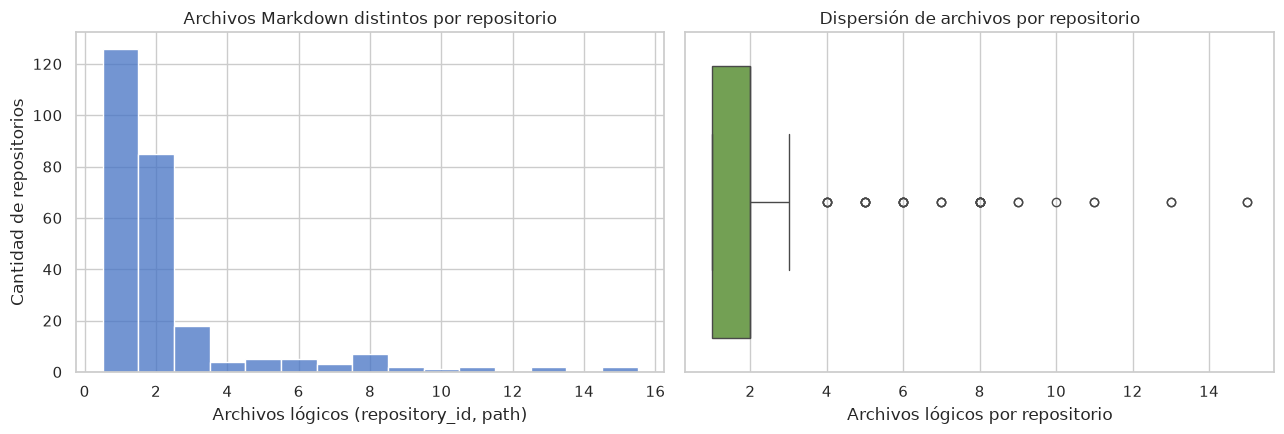

Umbral de cantidad especialmente alta (regla 1.5 IQR): 3.50


,repository_id,repo_full_name,markdown_files,snapshots,median_body_words
63,2354269869500930098,baizhiheizi/quill,15,40,1669.0
76,2696056629267340882,microsoft/vstest,15,47,768.0
62,2345438738015705176,Azure/azure-sdk-for-js,13,157,573.0
167,6324492700089473902,elastic/terraform-provider-elasticstack,13,205,723.0
141,5021593541857298325,github/copilot-sdk,11,38,609.0
73,2650957165291601970,tosin2013/mcp-adr-analysis-server,11,32,565.5
3,140853249158931842,pydantic/pydantic-ai,10,33,4.0
80,2795397534575803555,carlkidcrypto/ezsnmp,9,62,443.0
215,7808370641011591755,dotnet/maui,9,39,592.0
152,5244920801330304568,Kong/kongctl,8,64,646.5


Extremos superiores:


,repository_id,repo_full_name,markdown_files,snapshots,median_body_words
76,2696056629267340882,microsoft/vstest,15,47,768.0
63,2354269869500930098,baizhiheizi/quill,15,40,1669.0
62,2345438738015705176,Azure/azure-sdk-for-js,13,157,573.0
167,6324492700089473902,elastic/terraform-provider-elasticstack,13,205,723.0
141,5021593541857298325,github/copilot-sdk,11,38,609.0
73,2650957165291601970,tosin2013/mcp-adr-analysis-server,11,32,565.5
3,140853249158931842,pydantic/pydantic-ai,10,33,4.0
80,2795397534575803555,carlkidcrypto/ezsnmp,9,62,443.0
215,7808370641011591755,dotnet/maui,9,39,592.0
174,6470374951093305003,runhey/OnmyojiAutoScript,8,26,370.0


Extremos inferiores:


,repository_id,repo_full_name,markdown_files,snapshots,median_body_words
43,1689116779471759733,Activiti/activiti-cloud,1,3,2352.0
157,5474339820167673824,Alfresco/alfresco-build-tools,1,5,2350.0
214,7797772443194946383,Alfresco/alfresco-ng2-components,1,3,2352.0
238,8518204026246414784,Azure/AppConfiguration-KubernetesProvider,1,1,508.0
11,447003100388842707,Azure/azure-sdk-for-python,1,1,233.0
158,5477510737580552527,Azure/azure-sdk-for-rust,1,10,551.0
203,7303114496563430975,BMayhew/awesome-sites-to-test-on,1,2,968.0
186,6771056765237327604,CliMA/ClimaAtmos.jl,1,3,472.0
160,5501452496953928002,CommunityToolkit/Aspire,1,5,403.0
250,8859497168539074494,DanWahlin/github-azure-agentic-journeys,1,7,953.0


In [2]:
files_by_repo = (
    analysis.groupby(["repository_id", "repo_full_name"], as_index=False)
    .agg(
        markdown_files=("path", "nunique"),
        snapshots=("source_markdown_file_snapshot_id", "size"),
        median_body_words=("body_word_count", "median"),
    )
)

file_distribution_summary = pd.DataFrame({
    "estadistico": ["mínimo", "máximo", "media", "mediana"],
    "archivos_markdown_distintos_por_repositorio": [
        files_by_repo.markdown_files.min(),
        files_by_repo.markdown_files.max(),
        round(files_by_repo.markdown_files.mean(), 2),
        files_by_repo.markdown_files.median(),
    ],
})
display(file_distribution_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(files_by_repo["markdown_files"], discrete=True, bins=range(1, int(files_by_repo["markdown_files"].max()) + 2), ax=axes[0], color="#4472C4")
axes[0].set_title("Archivos Markdown distintos por repositorio")
axes[0].set_xlabel("Archivos lógicos (repository_id, path)")
axes[0].set_ylabel("Cantidad de repositorios")
sns.boxplot(x=files_by_repo["markdown_files"], ax=axes[1], color="#70AD47")
axes[1].set_title("Dispersión de archivos por repositorio")
axes[1].set_xlabel("Archivos lógicos por repositorio")
plt.tight_layout()
plt.show()

q1, q3 = files_by_repo["markdown_files"].quantile([0.25, 0.75])
iqr = q3 - q1
high_cutoff = q3 + 1.5 * iqr
special_repositories = files_by_repo.loc[
    (files_by_repo["markdown_files"] >= high_cutoff)
    | (files_by_repo["markdown_files"] == files_by_repo["markdown_files"].min())
].sort_values(["markdown_files", "repo_full_name"], ascending=[False, True])
print(f"Umbral de cantidad especialmente alta (regla 1.5 IQR): {high_cutoff:.2f}")
display(special_repositories.head(15))
print("Extremos superiores:")
display(files_by_repo.sort_values("markdown_files", ascending=False).head(10))
print("Extremos inferiores:")
display(files_by_repo.sort_values(["markdown_files", "repo_full_name"]).head(10))


La distribución está concentrada en repositorios con uno o dos archivos lógicos, mientras que unos pocos repositorios reúnen muchas rutas. El histograma y la tabla de extremos permiten identificar ese sesgo sin confundirlo con repositorios que simplemente tienen más versiones históricas.

## 3. Exploración del frontmatter

La cobertura se calcula sobre snapshots (2.820 archivos observados). Para atributos con varios valores, como on, permissions y tools, se cuenta cada valor declarado una vez por snapshot. Por eso sus porcentajes no son mutuamente excluyentes y pueden sumar más de 100%; engine se resume en un único identificador por snapshot cuando está disponible.

In [3]:
n_snapshots = len(analysis)
field_coverage = (
    field_presence.groupby("field")["source_markdown_file_snapshot_id"]
    .nunique()
    .sort_values(ascending=False)
    .rename("archivos")
    .rename_axis("campo")
    .reset_index()
)
field_coverage["porcentaje"] = (field_coverage["archivos"] / n_snapshots * 100).round(2)
display(field_coverage)


,campo,archivos,porcentaje
0,on,2813,99.75
1,permissions,2794,99.08
2,safe-outputs,2651,94.01
3,tools,2541,90.11
4,description,2406,85.32
5,network,2122,75.25
6,timeout-minutes,1983,70.32
7,engine,1279,45.35
8,steps,872,30.92
9,name,867,30.74


### Atributo 1: eventos de activación (on)

Se cuentan las claves declaradas dentro de on; un workflow puede tener simultáneamente, por ejemplo, schedule y workflow_dispatch.

,valor,archivos,porcentaje_de_archivos
0,workflow_dispatch,2021,71.67
1,schedule,1380,48.94
2,slash_command,599,21.24
3,reaction,532,18.87
4,steps,418,14.82
5,issues,400,14.18
6,roles,330,11.70
7,permissions,299,10.60
8,pull_request,290,10.28
9,pull_request_target,217,7.70


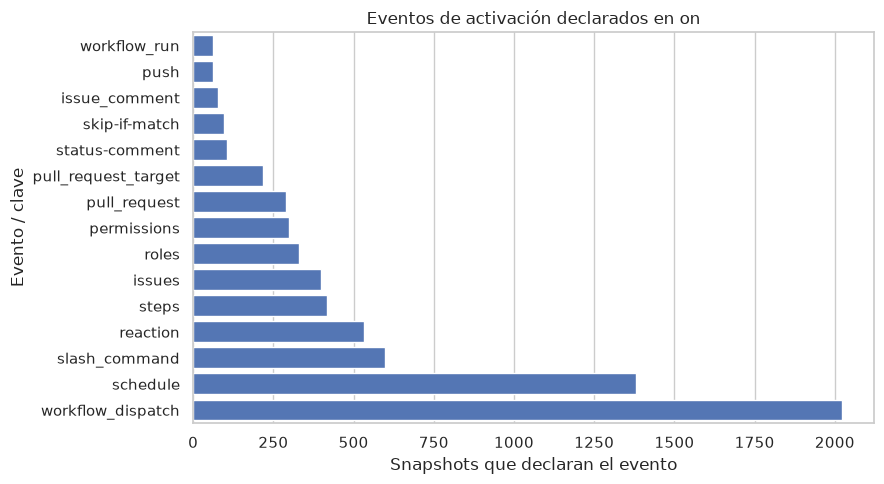

In [4]:
def frequency_table(attribute):
    values = attribute_values.loc[attribute_values["attribute"] == attribute]
    frequency = (
        values.groupby("value")["source_markdown_file_snapshot_id"]
        .nunique()
        .sort_values(ascending=False)
        .rename("archivos")
        .rename_axis("valor")
        .reset_index()
    )
    frequency["porcentaje_de_archivos"] = (frequency["archivos"] / n_snapshots * 100).round(2)
    return frequency

on_frequency = frequency_table("on")
display(on_frequency)

plot_data = on_frequency.head(15).sort_values("archivos")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x="archivos", y="valor", color="#4472C4")
plt.title("Eventos de activación declarados en on")
plt.xlabel("Snapshots que declaran el evento")
plt.ylabel("Evento / clave")
plt.tight_layout()
plt.show()


workflow_dispatch y schedule son los mecanismos dominantes. La suma de porcentajes puede superar 100% porque un mismo archivo puede declarar más de un evento.

### Atributo 2: motor de IA (engine)

engine se cuenta como un único valor por snapshot: si es un mapping se usa su clave id; los tres mappings sin id quedan como MAPA_SIN_ID y los ausentes como NO_DECLARADO.

,valor,archivos,porcentaje_de_archivos
0,NO_DECLARADO,1541,54.65
1,copilot,875,31.03
2,claude,345,12.23
3,codex,55,1.95
4,MAPA_SIN_ID,3,0.11
5,gemini,1,0.04


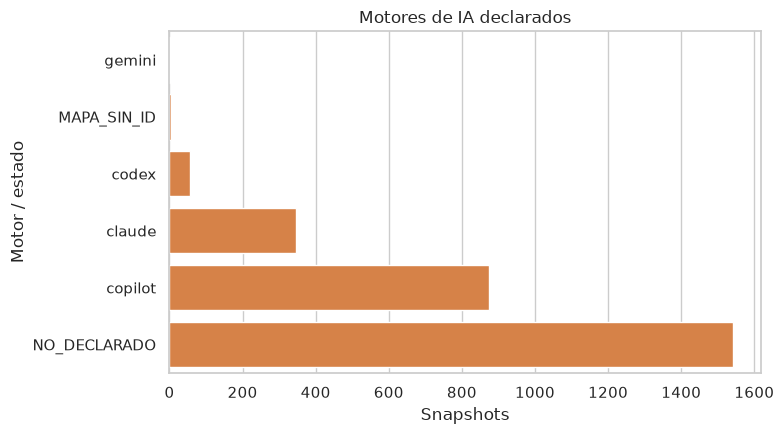

In [5]:
engine_frequency = frequency_table("engine")
display(engine_frequency)

plot_data = engine_frequency.sort_values("archivos")
plt.figure(figsize=(8, 4.5))
sns.barplot(data=plot_data, x="archivos", y="valor", color="#ED7D31")
plt.title("Motores de IA declarados")
plt.xlabel("Snapshots")
plt.ylabel("Motor / estado")
plt.tight_layout()
plt.show()


La ausencia de engine es frecuente; entre los valores explícitos predominan copilot y claude, seguidos por codex y un caso aislado de gemini. La ausencia no se imputa: puede significar que el workflow usa el motor predeterminado o que la versión no lo declaraba.

### Atributo 3: permisos (permissions)

Cada clave de permisos se cuenta como un valor independiente. Los valores escalares como read-all se conservan como tales.

,valor,archivos,porcentaje_de_archivos
0,contents,1964,69.65
1,pull-requests,1660,58.87
2,issues,1385,49.11
3,read-all,738,26.17
4,actions,554,19.65
5,id-token,134,4.75
6,copilot-requests,101,3.58
7,checks,75,2.66
8,security-events,43,1.52
9,discussions,37,1.31


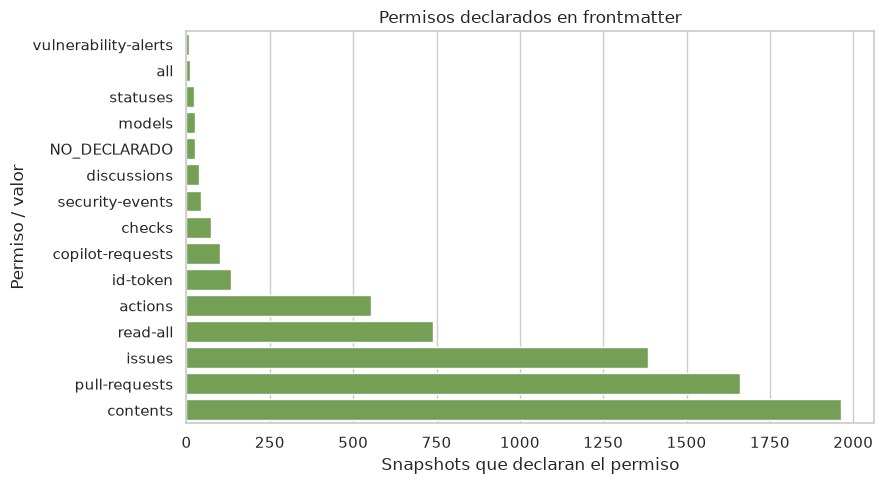

In [6]:
permissions_frequency = frequency_table("permissions")
display(permissions_frequency)

plot_data = permissions_frequency.head(15).sort_values("archivos")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x="archivos", y="valor", color="#70AD47")
plt.title("Permisos declarados en frontmatter")
plt.xlabel("Snapshots que declaran el permiso")
plt.ylabel("Permiso / valor")
plt.tight_layout()
plt.show()


contents, pull-requests e issues son las claves de permisos más extendidas. Como varios permisos pueden convivir en un mismo frontmatter, estas frecuencias describen adopción de capacidades, no una clasificación exclusiva.

### Atributo 4: herramientas (tools)

Se contabiliza cada nombre de herramienta declarado dentro del mapping tools.

,valor,archivos,porcentaje_de_archivos
0,github,2321,82.30
1,bash,1369,48.55
2,web-fetch,792,28.09
3,repo-memory,598,21.21
4,edit,411,14.57
5,cache-memory,330,11.70
6,NO_DECLARADO,279,9.89
7,playwright,61,2.16
8,timeout,36,1.28
9,cli-proxy,35,1.24


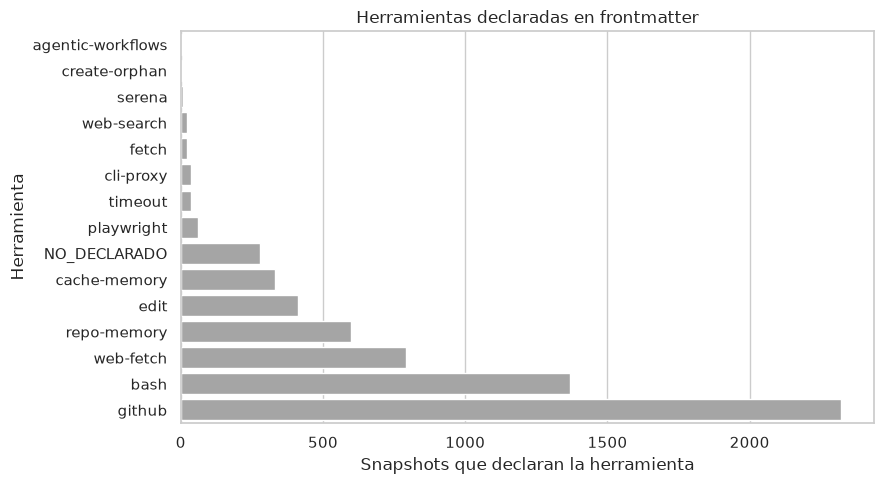

In [7]:
tools_frequency = frequency_table("tools")
display(tools_frequency)

plot_data = tools_frequency.head(15).sort_values("archivos")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x="archivos", y="valor", color="#A5A5A5")
plt.title("Herramientas declaradas en frontmatter")
plt.xlabel("Snapshots que declaran la herramienta")
plt.ylabel("Herramienta")
plt.tight_layout()
plt.show()


github es la herramienta más extendida, seguida por bash, web-fetch y herramientas de memoria. La interpretación debe considerar que el dataset captura configuraciones declaradas, no necesariamente llamadas efectivamente durante una ejecución.

## 4. Exploración del body

La longitud se mide como cantidad de tokens que coinciden con palabras Unicode, incluyendo palabras con guion o apóstrofe. La unidad sigue siendo un snapshot Markdown, no un archivo lógico deduplicado.

,estadistico,palabras_en_body
0,mínimo,4.00
1,máximo,7383.00
2,media,1141.74
3,mediana,765.00


Snapshots con body vacío: 0 de 2820


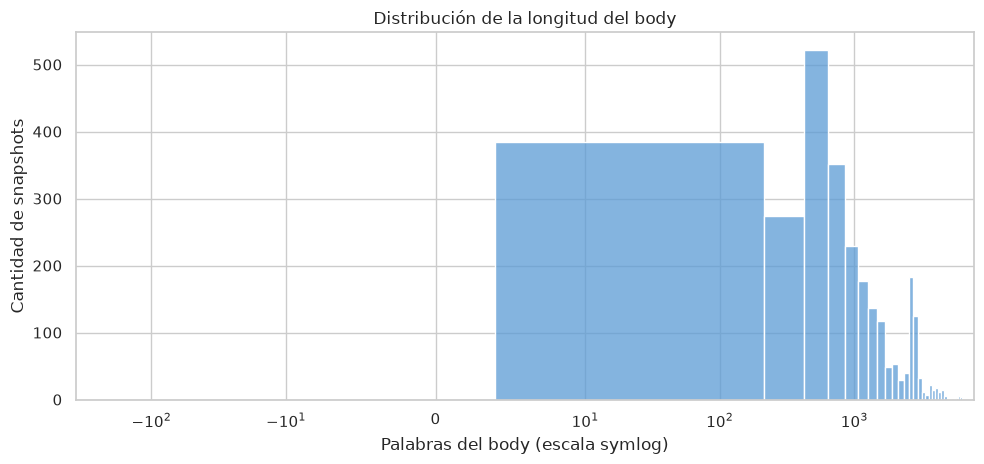

Snapshots con body más corto:


,repo_full_name,path,body_word_count,source_markdown_file_snapshot_id
235,pulumi/pulumi-vsphere,.github/workflows/gh-aw-pr-review.md,4,236
237,pulumi/pulumi-openstack,.github/workflows/gh-aw-pr-review.md,4,238
239,pulumi/pulumi-eks,.github/workflows/gh-aw-pr-review.md,4,240
301,pulumi/pulumi-random,.github/workflows/gh-aw-pr-review.md,4,302
580,pulumi/pulumi-postgresql,.github/workflows/gh-aw-pr-review.md,4,581
582,pulumi/pulumi-linode,.github/workflows/gh-aw-pr-review.md,4,583
602,pulumi/pulumi-kubernetes-operator,.github/workflows/kubernetes-operator-pr-review.md,4,603
603,pulumi/pulumi-kubernetes-operator,.github/workflows/kubernetes-operator-pr-review.md,4,604
606,pulumi/pulumi-terraform,.github/workflows/gh-aw-pr-review.md,4,607
608,pulumi/pulumi-digitalocean,.github/workflows/gh-aw-pr-review.md,4,609


Snapshots con body más largo:


,repo_full_name,path,body_word_count,source_markdown_file_snapshot_id
1389,dotnet/fsharp,.github/workflows/agentic-state-machine.md,7383,1390
1264,microsoft/aspire,.github/workflows/milestone-changelog.md,6207,1265
1265,microsoft/aspire,.github/workflows/milestone-changelog.md,6207,1266
1266,microsoft/aspire,.github/workflows/milestone-changelog.md,6207,1267
1263,microsoft/aspire,.github/workflows/milestone-changelog.md,6195,1264
1261,microsoft/aspire,.github/workflows/milestone-changelog.md,6105,1262
1262,microsoft/aspire,.github/workflows/milestone-changelog.md,6105,1263
1259,microsoft/aspire,.github/workflows/milestone-changelog.md,6092,1260
1260,microsoft/aspire,.github/workflows/milestone-changelog.md,6092,1261
278,dotnet/runtime,.github/workflows/ci-failure-scan.md,6054,279


In [8]:
body_summary = pd.DataFrame({
    "estadistico": ["mínimo", "máximo", "media", "mediana"],
    "palabras_en_body": [
        analysis.body_word_count.min(),
        analysis.body_word_count.max(),
        round(analysis.body_word_count.mean(), 2),
        analysis.body_word_count.median(),
    ],
})
display(body_summary)
print(f"Snapshots con body vacío: {int(analysis.body_empty.sum())} de {len(analysis)}")

plt.figure(figsize=(10, 4.8))
sns.histplot(analysis["body_word_count"], bins=35, color="#5B9BD5")
plt.xscale("symlog", linthresh=10)
plt.title("Distribución de la longitud del body")
plt.xlabel("Palabras del body (escala symlog)")
plt.ylabel("Cantidad de snapshots")
plt.tight_layout()
plt.show()

example_columns = ["repo_full_name", "path", "body_word_count", "source_markdown_file_snapshot_id"]
print("Snapshots con body más corto:")
display(analysis.nsmallest(10, "body_word_count")[example_columns])
print("Snapshots con body más largo:")
display(analysis.nlargest(10, "body_word_count")[example_columns])


No hay bodies vacíos en esta extracción. La media es mayor que la mediana, señal de una cola derecha: unos pocos workflows tienen cuerpos mucho más extensos que el caso típico. Los ejemplos extremos se muestran con repositorio y ruta para que puedan auditarse.

## 5. Relaciones entre variables

### Pregunta 1 — ¿Cómo varía la longitud del body según el motor de IA declarado?

Variables y tablas: body_word_count y engine de markdown_analysis.parquet, construidas desde los snapshots Markdown. Se compara cantidad de observaciones, media y mediana; no se interpreta como efecto causal.

,engine,snapshots,media_palabras,mediana_palabras,minimo,maximo
0,NO_DECLARADO,1541,1213.82,795.0,4,7383
1,copilot,875,1174.22,747.0,6,6054
2,claude,345,850.02,785.0,4,3161
3,codex,55,459.80,432.0,31,1535
4,MAPA_SIN_ID,3,908.00,908.0,908,908
5,gemini,1,496.00,496.0,496,496


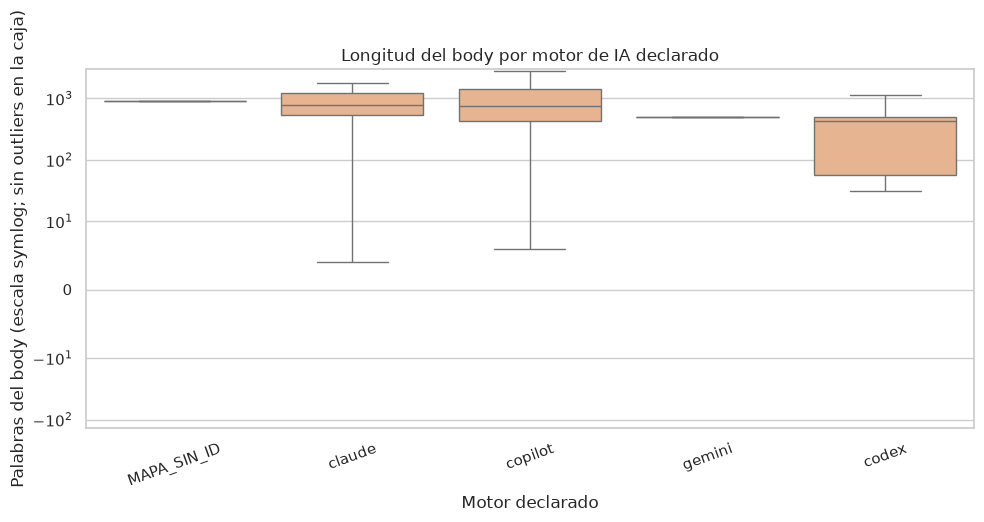

In [9]:
engine_body_summary = (
    analysis.groupby("engine", dropna=False)
    .agg(
        snapshots=("source_markdown_file_snapshot_id", "size"),
        media_palabras=("body_word_count", "mean"),
        mediana_palabras=("body_word_count", "median"),
        minimo=("body_word_count", "min"),
        maximo=("body_word_count", "max"),
    )
    .round(2)
    .sort_values("snapshots", ascending=False)
    .reset_index()
)
display(engine_body_summary)

plot_data = analysis.loc[analysis["engine"] != "NO_DECLARADO"].copy()
order = plot_data.groupby("engine")["body_word_count"].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_data, x="engine", y="body_word_count", order=order, showfliers=False, color="#F4B183")
plt.yscale("symlog", linthresh=10)
plt.title("Longitud del body por motor de IA declarado")
plt.xlabel("Motor declarado")
plt.ylabel("Palabras del body (escala symlog; sin outliers en la caja)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


La tabla y el boxplot permiten comparar distribuciones, pero la categoría NO_DECLARADO es grande y las categorías explícitas tienen tamaños muy distintos. Por ello, cualquier diferencia de longitud se reporta como asociación descriptiva y no como efecto del motor.

### Pregunta 2 — ¿La popularidad del repositorio se relaciona con la cantidad de archivos Markdown?

Variables y tablas: se agrupa markdown_analysis.parquet por repository_id y path para contar archivos lógicos; después se combina con repository.parquet mediante repository_id para incorporar stars. La relación se resume con correlación de rangos calculada sin asumir normalidad.

Correlación de rangos entre stars y archivos Markdown: 0.001


,repository_id,markdown_files,snapshots,repo_full_name,stars,main_language,stars_rank,files_rank
76,2696056629267340882,15,47,microsoft/vstest,963,C#,206.0,261.5
63,2354269869500930098,15,40,baizhiheizi/quill,70,Ruby,108.0,261.5
62,2345438738015705176,13,157,Azure/azure-sdk-for-js,2295,TypeScript,218.0,259.5
167,6324492700089473902,13,205,elastic/terraform-provider-elasticstack,208,Go,156.0,259.5
141,5021593541857298325,11,38,github/copilot-sdk,9464,Java,244.0,257.5
73,2650957165291601970,11,32,tosin2013/mcp-adr-analysis-server,30,TypeScript,67.5,257.5
3,140853249158931842,10,33,pydantic/pydantic-ai,18030,Python,248.0,256.0
215,7808370641011591755,9,39,dotnet/maui,23277,C#,252.0,254.5
80,2795397534575803555,9,62,carlkidcrypto/ezsnmp,34,C++,71.0,254.5
174,6470374951093305003,8,26,runhey/OnmyojiAutoScript,4404,Python,231.0,250.0


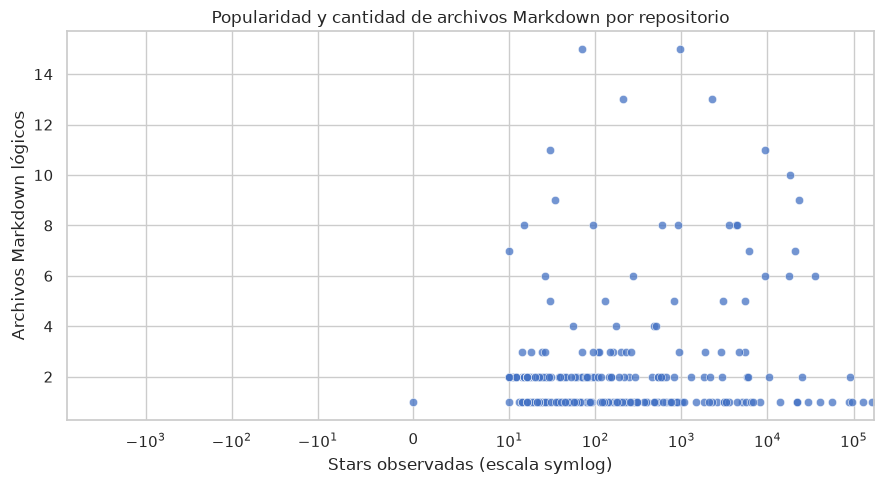

In [10]:
repo_file_relation = (
    analysis.groupby("repository_id", as_index=False)
    .agg(
        markdown_files=("path", "nunique"),
        snapshots=("source_markdown_file_snapshot_id", "size"),
    )
    .merge(
        repositories[["repository_id", "repo_full_name", "stars", "main_language"]],
        on="repository_id",
        how="left",
        validate="one_to_one",
    )
)
repo_file_relation["stars_rank"] = repo_file_relation["stars"].rank(method="average")
repo_file_relation["files_rank"] = repo_file_relation["markdown_files"].rank(method="average")
spearman_rho = repo_file_relation["stars_rank"].corr(repo_file_relation["files_rank"])
print(f"Correlación de rangos entre stars y archivos Markdown: {spearman_rho:.3f}")
display(repo_file_relation.sort_values(["markdown_files", "stars"], ascending=False).head(15))

plt.figure(figsize=(9, 5))
sns.scatterplot(data=repo_file_relation, x="stars", y="markdown_files", alpha=0.75, color="#4472C4")
plt.xscale("symlog", linthresh=10)
plt.title("Popularidad y cantidad de archivos Markdown por repositorio")
plt.xlabel("Stars observadas (escala symlog)")
plt.ylabel("Archivos Markdown lógicos")
plt.tight_layout()
plt.show()


En esta muestra, la correlación de rangos es prácticamente nula, por lo que no se observa una relación monotónica clara entre stars y número de archivos. Hay repositorios populares con pocas rutas y repositorios menos populares con muchas; la cobertura y la selección de early adopters limitan cualquier generalización.

## 6. Hallazgos y limitaciones

In [11]:
on_count = int((field_coverage.loc[field_coverage["campo"] == "on", "archivos"]).iloc[0])
permissions_count = int((field_coverage.loc[field_coverage["campo"] == "permissions", "archivos"]).iloc[0])
tools_count = int((field_coverage.loc[field_coverage["campo"] == "tools", "archivos"]).iloc[0])
engine_declared = int((analysis["engine"] != "NO_DECLARADO").sum())
logical_files = analysis[["repository_id", "path"]].drop_duplicates().shape[0]
findings = pd.DataFrame([
    {
        "hallazgo": "El dataset es longitudinal",
        "resultado": f"{len(analysis):,} snapshots corresponden a {logical_files:,} archivos lógicos en {analysis.repository_id.nunique():,} repositorios.",
        "respaldo": "conteos de unidad y distribución por repositorio",
    },
    {
        "hallazgo": "Los eventos y permisos tienen alta cobertura",
        "resultado": f"on aparece en {on_count:,} snapshots ({on_count / len(analysis) * 100:.1f}%), permissions en {permissions_count:,} ({permissions_count / len(analysis) * 100:.1f}%) y tools en {tools_count:,} ({tools_count / len(analysis) * 100:.1f}%).",
        "respaldo": "tabla de cobertura y frecuencias de frontmatter",
    },
    {
        "hallazgo": "El motor no siempre está declarado",
        "resultado": f"Solo {engine_declared:,} de {len(analysis):,} snapshots tienen un engine identificable; predominan los valores mostrados en la tabla de frecuencias.",
        "respaldo": "frecuencia de engine y boxplot de body",
    },
    {
        "hallazgo": "Los bodies no están vacíos y presentan asimetría",
        "resultado": f"La mediana es {analysis.body_word_count.median():.0f} palabras frente a una media de {analysis.body_word_count.mean():.0f}; el máximo es {analysis.body_word_count.max():.0f}.",
        "respaldo": "estadísticos y distribución del body",
    },
    {
        "hallazgo": "Stars no explica la cantidad de archivos en esta muestra",
        "resultado": f"La correlación de rangos observada es {spearman_rho:.3f}.",
        "respaldo": "join repository_id, tabla de relación y dispersión",
    },
])
display(findings)


,hallazgo,resultado,respaldo
0,El dataset es longitudinal,"2,820 snapshots corresponden a 604 archivos lógicos en 262 repositorios.",conteos de unidad y distribución por repositorio
1,Los eventos y permisos tienen alta cobertura,"on aparece en 2,813 snapshots (99.8%), permissions en 2,794 (99.1%) y tools ...",tabla de cobertura y frecuencias de frontmatter
2,El motor no siempre está declarado,"Solo 1,279 de 2,820 snapshots tienen un engine identificable; predominan los...",frecuencia de engine y boxplot de body
3,Los bodies no están vacíos y presentan asimetría,La mediana es 765 palabras frente a una media de 1142; el máximo es 7383.,estadísticos y distribución del body
4,Stars no explica la cantidad de archivos en esta muestra,La correlación de rangos observada es 0.001.,"join repository_id, tabla de relación y dispersión"


### Limitaciones

- Cobertura: GHAW-H contiene 262 repositorios early-adopter y no es una muestra aleatoria de GitHub.
- Dependencia temporal: las 2.820 filas son snapshots/versiones; no son observaciones independientes.
- Valores ausentes: hay licencias y lenguajes no informados, extremos sin predecessor/successor, seis frontmatters vacíos y un YAML inválido. No se imputaron ni excluyeron.
- Campos no declarados: la ausencia de engine, permisos o herramientas puede representar configuración predeterminada, evolución del formato o falta de registro.
- Popularidad: stars es una medición observada en la recolección; la correlación descriptiva no implica causalidad.
- Contenido: el body se mide con una regla simple de palabras y el dataset conserva contenidos sujetos a las licencias de sus repositorios de origen.